## SeaTurtleID2022 Dataset Exploration and Masks Visualisation

In [1]:
import numpy
from pycocotools.coco import COCO

In [2]:
import os
import glob
import json
import pandas as pd 
from pycocotools.coco import COCO
from PIL import Image
import numpy as np 
import skimage.io as io
from matplotlib import pyplot as plt
from pprint import pprint
%matplotlib inline


## Loading and exploring data

In [3]:
with open('annotations.json', 'r', encoding='utf8') as file:
    data = json.load(file)

In [4]:
data.keys()

dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])

In [5]:
# Let's print out the first few image filenames/paths
for img in data['images'][:10]:
    print(img['file_name'])

images/t001/CAluWEgwPX.JPG
images/t001/EKyrFKHQzh.JPG
images/t001/ELAvEqeXxT.JPG
images/t001/IxRLFwTGCv.JPG
images/t001/LKCJAhfLBJ.JPG
images/t001/LZystXlIqe.JPG
images/t001/OiaMESWPyh.JPG
images/t001/VMyJozldvy.jpg
images/t001/XhbkFIOvZr.JPG
images/t001/ZKnMahXQgJ.JPG


In [6]:
# Let's see first annotation
for ann in data['annotations'][:1]:
    for key, value in ann.items():
        print(key)
        print(value)
        print("********")
    print("--------------------------------")
    

id
1
********
image_id
1
********
category_id
3
********
segmentation
{'counts': [858927, 7, 1322, 23, 1306, 34, 1298, 36, 1296, 39, 1292, 42, 1291, 43, 1289, 45, 1287, 47, 1285, 48, 1285, 49, 1283, 51, 1281, 53, 1280, 54, 1278, 56, 1277, 56, 1277, 57, 1275, 58, 1274, 60, 1273, 61, 1272, 61, 1272, 62, 1270, 63, 1269, 64, 1268, 65, 1268, 65, 1268, 66, 1267, 67, 1266, 67, 1265, 68, 1264, 69, 1263, 70, 1263, 70, 1263, 70, 1263, 70, 1263, 70, 1263, 70, 1262, 71, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1261, 72, 1260, 73, 1260, 73, 1260, 73, 1259, 74, 1258, 75, 1258, 74, 1259, 73, 1260, 72, 1261, 71, 1262, 69, 1263, 69, 1264, 68, 1265, 66, 1266, 64, 1269, 63, 1269, 61, 1272, 59, 1274, 58, 1275, 55, 1278, 52, 1281, 15, 8, 25, 1285, 12, 16, 17, 1289, 9, 24, 3, 1297, 7, 1327, 4, 1715124], 'size': [1333, 2000]}
********
area
4065.0
********
bbox
[644.0, 441.0, 70.0, 78.0]
********
iscrowd
1
********
attributes
{'orientation': 'left', 'occluded': False}
********
-------------

##  Using COCO API (Recommended)

In [7]:
# initialise COCO API for annotations
coco = COCO('annotations.json')

loading annotations into memory...
Done (t=1.64s)
creating index...
index created!


In [8]:
for key in coco.anns.keys():
    pprint(coco.anns[key])
    break 

{'area': 4065.0,
 'attributes': {'occluded': False, 'orientation': 'left'},
 'bbox': [644.0, 441.0, 70.0, 78.0],
 'category_id': 3,
 'id': 1,
 'image_id': 1,
 'iscrowd': 1,
 'segmentation': {'counts': [858927,
                             7,
                             1322,
                             23,
                             1306,
                             34,
                             1298,
                             36,
                             1296,
                             39,
                             1292,
                             42,
                             1291,
                             43,
                             1289,
                             45,
                             1287,
                             47,
                             1285,
                             48,
                             1285,
                             49,
                             1283,
                             51,
          

## Elements of COCO Category

We have three categories in this datset. 
- supercategory: parent class of the child class (i.e. giraffe is an Animal, supercategory: Animal)
- id: integer that corresponds to category
- name: English word that defines category

In [9]:
for i in range(1,4):
    print(coco.cats[i])

{'id': 1, 'name': 'turtle', 'supercategory': ''}
{'id': 2, 'name': 'flipper', 'supercategory': ''}
{'id': 3, 'name': 'head', 'supercategory': ''}


In [10]:
# you can also get all categories using coco.getCatIds
coco.getCatIds()

[1, 2, 3]

In [11]:
# get metadata of coco categories
coco.loadCats(coco.getCatIds()) # returns dictionary

[{'id': 1, 'name': 'turtle', 'supercategory': ''},
 {'id': 2, 'name': 'flipper', 'supercategory': ''},
 {'id': 3, 'name': 'head', 'supercategory': ''}]

## Elements in COCO Image

Important ones for this dataset are:
- file_name: path of the image
- height: an integer value representing height of the image in pixels
- width: an integer value representing width of the image in pixels
- id: a unique identifier for the image

In [12]:
for key in coco.imgs.keys():
    pprint(coco.imgs[key])
    break

{'coco_url': '',
 'date_captured': 0,
 'file_name': 'images/t001/CAluWEgwPX.JPG',
 'flickr_url': '',
 'height': 1333,
 'id': 1,
 'identity': 't001',
 'license': 0,
 'timestamp': '2014:07:14 14:49:45',
 'width': 2000}


## Important functions

We can use the following functions to get particular data item:
- ``loadAnns``: load anns with the specified ids
- ``loadCats``: load cats with the specified ids
- ``loadImgs``: load imgs with the specified ids

In [13]:
im = coco.loadImgs(59)[0]
pprint(im)

{'coco_url': '',
 'date_captured': 0,
 'file_name': 'images/t003/zlkamyNHCP.jpg',
 'flickr_url': '',
 'height': 1124,
 'id': 59,
 'identity': 't003',
 'license': 0,
 'timestamp': '2010:08:23 23:19:04',
 'width': 2000}


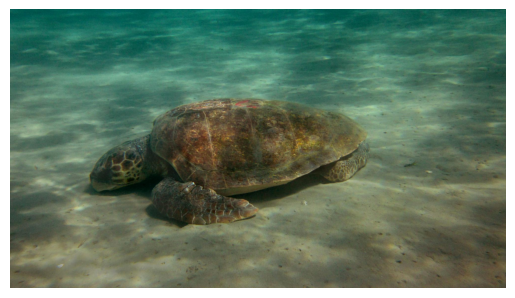

In [14]:
I = io.imread(im['file_name'])
plt.axis('off')
plt.imshow(I)
plt.show()

## Visualizing data and annotations

In [15]:
img_dir = 'images/'
image_id = 7
img = coco.imgs[image_id]
img

{'id': 7,
 'width': 2000,
 'height': 1333,
 'file_name': 'images/t001/OiaMESWPyh.JPG',
 'license': 0,
 'flickr_url': '',
 'coco_url': '',
 'date_captured': 0,
 'timestamp': '2014:07:14 14:52:17',
 'identity': 't001'}

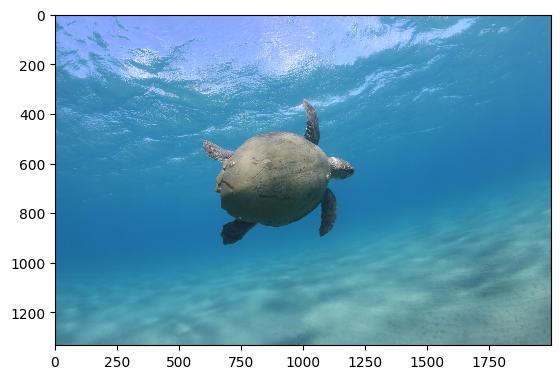

In [16]:
# Let's display the image
image = np.array(Image.open(img['file_name']))
plt.imshow(image, interpolation='nearest')
plt.show()

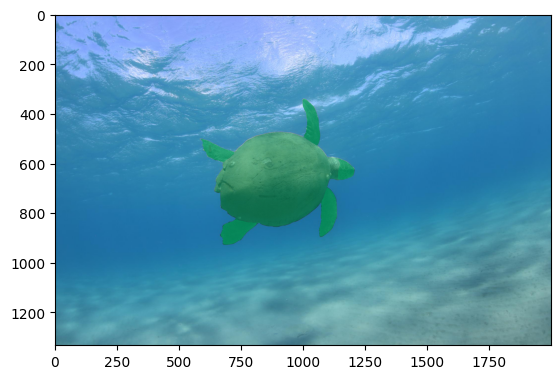

In [17]:
# Let's overlay annotations
plt.imshow(image)
cat_ids = coco.getCatIds()
anns_ids = coco.getAnnIds(imgIds=img['id'], catIds=cat_ids, iscrowd=None)
anns = coco.loadAnns(anns_ids)
coco.showAnns(anns)

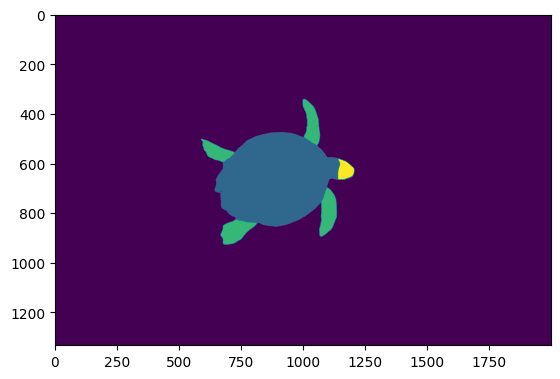

In [18]:
mask = coco.annToMask(anns[0])
for i in range(len(anns)):
    mask += coco.annToMask(anns[i])
plt.imshow(mask)

## Let's see one more example

In [19]:
image_id = 77
img = coco.imgs[image_id]
img

{'id': 77,
 'width': 2000,
 'height': 1124,
 'file_name': 'images/t004/MzIRwubLJv.jpg',
 'license': 0,
 'flickr_url': '',
 'coco_url': '',
 'date_captured': 0,
 'timestamp': '2010:07:10',
 'identity': 't004'}

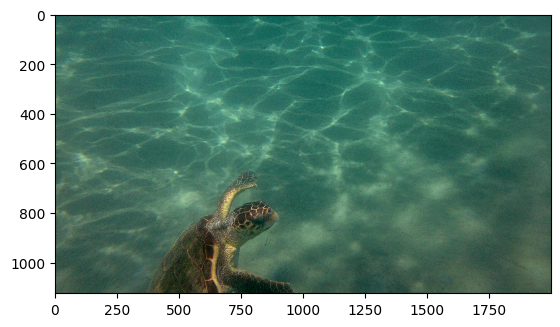

In [20]:
# Let's display the image
image = np.array(Image.open(img['file_name']))
plt.imshow(image, interpolation='nearest')
plt.show()

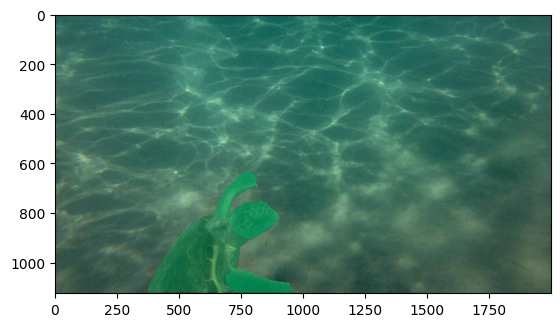

In [21]:
# Let's overlay annotations
plt.imshow(image)
cat_ids = coco.getCatIds()
anns_ids = coco.getAnnIds(imgIds=img['id'], catIds=cat_ids, iscrowd=None)
anns = coco.loadAnns(anns_ids)
coco.showAnns(anns)

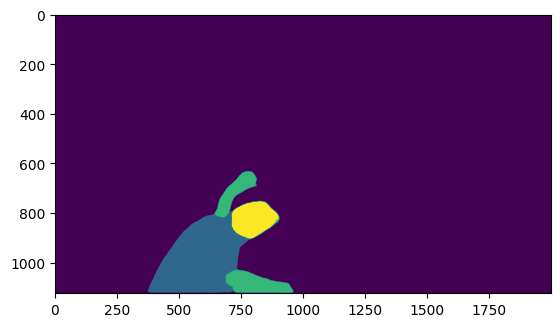

In [22]:
mask = coco.annToMask(anns[0])
for i in range(len(anns)):
    mask += coco.annToMask(anns[i])
plt.imshow(mask)

In [23]:
import os
import shutil
from tqdm import tqdm

# 源文件夹路径，包含多个子文件夹
source_dir = './images'

# 目标文件夹路径
target_dir = './datasets/turtle_merge/images'

# 如果目标文件夹不存在，则创建它
os.makedirs(target_dir, exist_ok=True)

# 定义支持的图像文件扩展名列表
image_extensions = {'.jpg', '.JPG', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif'}

# 首先收集所有要复制的文件
files_to_copy = []
for root, dirs, files in os.walk(source_dir):
    for file in files:
        if os.path.splitext(file)[1].lower() in image_extensions:
            files_to_copy.append(os.path.join(root, file))

# 使用 tqdm 显示进度条
for file_path in tqdm(files_to_copy, desc="复制图片"):
    file_name = os.path.basename(file_path)
    target_file_path = os.path.join(target_dir, file_name)

    # 检查目标目录中是否已存在同名文件，若存在则重命名
    original_target_file_path = target_file_path
    counter = 1
    while os.path.exists(target_file_path):
        # 文件名和扩展名
        name, extension = os.path.splitext(original_target_file_path)
        target_file_path = f"{name}_{counter}{extension}"
        counter += 1

    # 复制文件
    shutil.copy(file_path, target_file_path)

print('所有图片已复制至目标文件夹。')

复制图片: 100%|██████████| 8729/8729 [00:03<00:00, 2420.40it/s]

所有图片已复制至目标文件夹。


In [24]:
import numpy as np
import os
from skimage import measure
from pycocotools.coco import COCO
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


# 指定注释文件
anno_file = 'annotations.json'
coco = COCO(anno_file)

# 指定我们感兴趣的类别
categories = ['turtle', 'flipper', 'head']
catIds = coco.getCatIds(catNms=categories)
print("catIds:", catIds)

# 获取这些类别的注释ID，其中 iscrowd=1
anno_ids = coco.getAnnIds(catIds=catIds, iscrowd=1)
annotations = coco.loadAnns(anno_ids)

# 创建一个文件夹来保存输出的txt文件
output_folder = './datasets/turtle_merge/labels'
os.makedirs(output_folder, exist_ok=True)


def process_annotation(annotation):
    # 获取RLE编码和对应的高宽
    rle = annotation['segmentation']['counts']
    height = annotation['segmentation']['size'][0]
    width = annotation['segmentation']['size'][1]
    assert sum(rle) == height * width, "Sum of RLE counts does not match the image area"

    # 创建并填充图像矩阵
    M = np.zeros(height * width)
    N = len(rle)
    n = 0
    val = 1
    for pos in range(N):
        val = not val
        for c in range(rle[pos]):
            M[n] = val
            n += 1

    # 重塑为二维图像
    GEMFIELD = M.reshape((height, width), order='F')

    # 提取轮廓线
    contours = measure.find_contours(GEMFIELD, 0.5)

    # 获取图像ID，并加载图像信息
    img_id = annotation['image_id']
    img_info = coco.loadImgs(img_id)[0]
    img_name = img_info['file_name']

    # 准备收集所有轮廓点
    contour_points = []

    for contour in contours:
        # 将轮廓的绝对坐标转换为相对坐标
        relative_contour = contour.copy()
        relative_contour[:, 0] = relative_contour[:, 0] / height
        relative_contour[:, 1] = relative_contour[:, 1] / width

        # 收集轮廓点
        for point in relative_contour:
            contour_points.append(f"{point[1]:.6f} {point[0]:.6f}")

    # 构建输出文件名，并只包含文件名部分
    txt_filename = os.path.join(output_folder, os.path.basename(f"{os.path.splitext(img_name)[0]}.txt"))
    with open(txt_filename, 'a') as file:
        # 写入类别ID和所有轮廓点
        file.write(f"{annotation['category_id']} " + ' '.join(contour_points) + "\n")


# 使用ThreadPoolExecutor来并行处理
with ThreadPoolExecutor(max_workers=16) as executor:
    list(tqdm(executor.map(process_annotation, annotations), total=len(annotations)))


print('convert finish')



loading annotations into memory...
Done (t=2.08s)
creating index...
index created!
catIds: [1, 2, 3]


100%|██████████| 38414/38414 [1:29:56<00:00,  7.12it/s]    

convert finish


## 划分数据集

In [30]:
import os  # 用于处理文件路径、创建目录等操作
import random  # 用于生成随机数种子、打乱列表等操作
import shutil  # 用于文件的复制操作
from tqdm import tqdm  # 引入 tqdm 库显示进度条

# 设置随机数种子
random.seed(123)

# 定义文件夹路径
image_dir = './datasets/turtle_merge/images'  # 原始图像所在的子目录
label_dir = './datasets/turtle_merge/labels'  # 原始标签所在的子目录
output_dir = './datasets/turtle'  # 处理后的数据集输出目录

try:
    shutil.rmtree(output_dir)
    print(f"文件夹 {output_dir} 及其所有内容已成功删除。")
except Exception as e:
    print(f"删除文件夹时出错：{e}")

# 获取所有图像文件名（支持 .jpg 和 .jpeg）
image_filenames = [
    os.path.splitext(f)[0] for f in os.listdir(image_dir) 
    if f.lower().endswith(('.jpg', '.jpeg'))
]
label_filenames = [
    os.path.splitext(f)[0] for f in os.listdir(label_dir)
    if f.lower().endswith('.txt')
]

# 获取所有图像文件和标签文件的文件名（不包括文件扩展名）
valid_filenames = [f for f in image_filenames if f in label_filenames]  # 提取所有图像文件的文件名列表

# 随机打乱文件名列表
random.shuffle(valid_filenames)  # 打乱图像文件的文件名列表

# 计算训练集、验证集和测试集的数量
total_count = len(valid_filenames)  # 总文件数
train_ratio = 0.7  # 训练集比例
valid_ratio = 0.2  # 验证集比例
test_ratio = 0.1  # 测试集比例
train_count = int(total_count * train_ratio)  # 训练集文件数
valid_count = int(total_count * valid_ratio)  # 验证集文件数
test_count = total_count - train_count - valid_count  # 测试集文件数

# 定义输出文件夹路径
train_image_dir = os.path.join(output_dir, 'images', 'train')  # 训练集图像输出目录
train_label_dir = os.path.join(output_dir, 'labels', 'train')  # 训练集标签输出目录
valid_image_dir = os.path.join(output_dir, 'images', 'val')  # 验证集图像输出目录
valid_label_dir = os.path.join(output_dir, 'labels', 'val')  # 验证集标签输出目录
test_image_dir = os.path.join(output_dir, 'images', 'test')  # 测试集图像输出目录
test_label_dir = os.path.join(output_dir, 'labels', 'test')  # 测试集标签输出目录

# 创建输出文件夹
os.makedirs(train_image_dir, exist_ok=True)
os.makedirs(train_label_dir, exist_ok=True)
os.makedirs(valid_image_dir, exist_ok=True)
os.makedirs(valid_label_dir, exist_ok=True)
os.makedirs(test_image_dir, exist_ok=True)
os.makedirs(test_label_dir, exist_ok=True)

# 将图像和标签文件划分到不同的数据集中
for i, filename in tqdm(enumerate(valid_filenames), total=total_count, desc="分割数据集"):
    if i < train_count:
        output_image_dir = train_image_dir
        output_label_dir = train_label_dir
    elif i < train_count + valid_count:
        output_image_dir = valid_image_dir
        output_label_dir = valid_label_dir
    else:
        output_image_dir = test_image_dir
        output_label_dir = test_label_dir
    
    # 查找图像文件的完整路径（支持 .jpg 和 .jpeg）
    src_image_path = None
    for ext in ['.jpg', '.jpeg']:
        temp_path = os.path.join(image_dir, filename + ext)
        if os.path.exists(temp_path):
            src_image_path = temp_path
            break

    if src_image_path is None:
        print(f"图像文件 {filename} 不存在，跳过。")
        continue

    # 复制图像文件
    dst_image_path = os.path.join(output_image_dir, os.path.basename(src_image_path))
    shutil.copy(src_image_path, dst_image_path)

    src_label_path = os.path.join(label_dir, filename + '.txt')
    dst_label_path = os.path.join(output_label_dir, filename + '.txt')
    shutil.copy(src_label_path, dst_label_path)

print('数据集划分完成')

文件夹 ./datasets/turtle 及其所有内容已成功删除。


分割数据集: 100%|██████████| 8726/8726 [00:06<00:00, 1252.58it/s]

数据集划分完成


In [35]:
#train datasets

from ultralytics import YOLO

# 加载模型
# model = YOLO("yolov8n.yaml")  # 从头开始构建新模型
model = YOLO("weights/yolov8n-seg.pt")  # 加载预训练模型（推荐用于训练）

if __name__ == '__main__':
    # Use the model
    results = model.train(data="data/turtle.yaml", epochs=50, batch=8,workers=8)  # 训练模型


New https://pypi.org/project/ultralytics/8.3.28 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.8.19 torch-2.4.1 CPU (Apple M3 Pro)
engine/trainer: task=segment, mode=train, model=weights/yolov8n-seg.pt, data=data/turtle.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, 

train: Scanning /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/labels/train... 6108 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6108/6108 [00:07<00:00, 812.41it/s]

train: WARNING ⚠️ /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/images/train/gYcjWIRQah.jpg: 1 duplicate labels removed


train: New cache created: /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/labels/train.cache


val: Scanning /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/labels/val... 1745 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1745/1745 [00:02<00:00, 772.83it/s]


...

      50/50         0G      0.428      0.558     0.2691     0.8446         17        640: 100%|██████████| 764/764 [23:27<00:00,  1.84s/it]
                 Class     Images  Instances      Box(P          R      mAP50   mAP50-95       iou)     Mask(P          R      mAP50   mAP50-95       iou): 100%|██████████| 110/110 [04:08<00:00,  2.26s/it]

                   all       1745       7640      0.973      0.971      0.986      0.901      0.152      0.974      0.962      0.984      0.838      0.152



50 epochs completed in 23.585 hours.
Optimizer stripped from runs/segment/train9/weights/last.pt, 6.8MB
Optimizer stripped from runs/segment/train9/weights/best.pt, 6.8MB

Validating runs/segment/train9/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.8.19 torch-2.4.1 CPU (Apple M3 Pro)
YOLOv8n-seg summary (fused): 195 layers, 3,258,844 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50   mAP50-95       iou)     Mask(P          R      mAP50   mAP50-95       iou): 100%|██████████| 110/110 [03:51<00:00,  2.10s/it]


                   all       1745       7640      0.973      0.971      0.986      0.901      0.152      0.974      0.962      0.984      0.838      0.152
                turtle       1744       1753      0.995      0.998      0.995      0.983      0.152      0.992      0.992      0.994      0.905      0.152
               flipper       1731       4185      0.946      0.934      0.969      0.841       0.15      0.955      0.924       0.97       0.79       0.15
                  head       1702       1702      0.978       0.98      0.993      0.879      0.153      0.975      0.968      0.987       0.82      0.153
Speed: 0.3ms preprocess, 116.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/segment/train9


In [36]:
# eval

from ultralytics import YOLO
if __name__ == '__main__':
    # 加载模型
    model = YOLO("runs/segment/train/weights/best.pt")  # 加载预训练模型（建议用于训练）

In [37]:
    # model = YOLO("best.pt")
    metrics = model.val(data="data/turtle.yaml",)  # 在验证集上评估模型性能
    a = 1


Ultralytics YOLOv8.2.103 🚀 Python-3.8.19 torch-2.4.1 CPU (Apple M3 Pro)
YOLOv8n-seg summary (fused): 195 layers, 3,258,844 parameters, 0 gradients, 12.0 GFLOPs


val: Scanning /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/labels/val.cache... 1745 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1745/1745 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50   mAP50-95       iou)     Mask(P          R      mAP50   mAP50-95       iou): 100%|██████████| 110/110 [03:55<00:00,  2.14s/it]


                   all       1745       7640      0.978      0.975      0.989       0.91      0.148      0.972      0.968      0.985      0.832      0.148
                turtle       1744       1753      0.996      0.999      0.995      0.986      0.153      0.992      0.995      0.994      0.911      0.153
               flipper       1731       4185      0.954      0.949      0.978       0.86      0.148      0.951      0.946      0.976      0.777      0.148
                  head       1702       1702      0.986      0.978      0.994      0.884      0.144      0.972      0.964      0.986      0.807      0.144
Speed: 0.3ms preprocess, 118.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/segment/val39



0: 448x640 1 turtle, 2 flippers, 1 head, 63.0ms
Speed: 2.2ms preprocess, 63.0ms inference, 3.7ms postprocess per image at shape (1, 3, 448, 640)


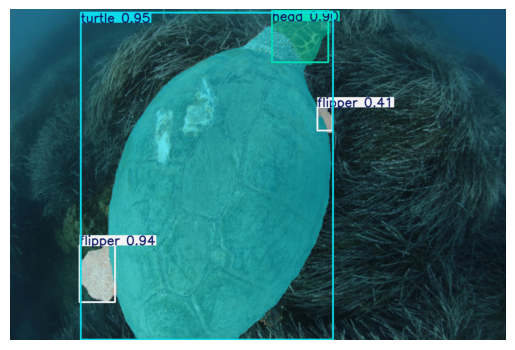

In [38]:
#visualize predict image
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline


model = YOLO("runs/segment/train/weights/best.pt")  # 加载预训练模型（推荐用于训练）
image =cv2.imread('datasets/turtle/images/train/aAIPugFRGe.jpg')
results = model.predict(source=image)  # 训练模型
annotated_frame = results[0].plot()
annotated_frame_rgb  = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
# cv2.imshow('results', annotated_frame)

plt.imshow(annotated_frame_rgb)
plt.axis('off')  # 不显示坐标轴
plt.show()


# cv2.waitKey(0)

In [40]:
#  test
from ultralytics import YOLO
if __name__ == '__main__':
    # 加载模型
    model = YOLO("runs/segment/train/weights/best.pt")  # 加载训练模型
    metrics = model.val(data="data/turtle.yaml",split = 'test')  # 在验证集上评估模型性能
    # metrics = model.val(data='data.yaml', split='test')
metrics

Ultralytics YOLOv8.2.103 🚀 Python-3.8.19 torch-2.4.1 CPU (Apple M3 Pro)
YOLOv8n-seg summary (fused): 195 layers, 3,258,844 parameters, 0 gradients, 12.0 GFLOPs


val: Scanning /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/labels/test... 873 images, 0 backgrounds, 0 corrupt: 100%|██████████| 873/873 [00:01<00:00, 753.03it/s]

val: New cache created: /Users/hyin/Desktop/9517project/ultralytics-8.2.103-turtle/datasets/turtle/labels/test.cache



                 Class     Images  Instances      Box(P          R      mAP50   mAP50-95       iou)     Mask(P          R      mAP50   mAP50-95       iou): 100%|██████████| 55/55 [01:57<00:00,  2.14s/it]


                   all        873       3821      0.976      0.971      0.985      0.906      0.151      0.975      0.955       0.98       0.82      0.151
                turtle        870        882      0.995      0.993      0.993      0.983      0.155       0.99      0.986       0.99      0.891      0.155
               flipper        866       2081      0.947       0.94       0.97      0.854      0.147      0.963      0.927      0.973      0.773      0.147
                  head        858        858      0.986      0.981      0.993      0.881      0.151      0.971      0.952      0.976      0.796      0.151
Speed: 0.4ms preprocess, 117.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/segment/val40


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x2c420ff70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104